In [ ]:
# HR Analytics: Employee Attrition Prediction

## Project Overview

Employee attrition is one of the major challenges faced by organizations. High attrition increases recruitment costs, reduces productivity, and affects business performance.

The objective of this project is to analyze employee data, identify the key factors influencing attrition, and build machine learning models capable of predicting whether an employee is likely to leave the organization.

## Objectives

- Perform Data Cleaning
- Perform Exploratory Data Analysis (EDA)
- Engineer relevant features
- Build Machine Learning Models
- Compare model performances
- Predict Employee Attrition

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Display Settings
pd.set_option('display.max_columns', None)

# Plot Style
sns.set_style("whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
df = pd.read_csv(r"C:\Users\PC\Downloads\people-1-2-1\people (1) (2).xls")   

df.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low


In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 14999
Columns : 10


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfactoryLevel      14999 non-null  float64
 1   lastEvaluation         14999 non-null  float64
 2   numberOfProjects       14999 non-null  int64  
 3   avgMonthlyHours        14999 non-null  int64  
 4   timeSpent.company      14999 non-null  int64  
 5   workAccident           14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotionInLast5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [6]:
df.describe()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [7]:
df.describe(include='object')

,dept,salary
count,14999,14999
unique,10,3
top,sales,low
freq,4140,7316


In [8]:
df.columns

Index(['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects',
       'avgMonthlyHours', 'timeSpent.company', 'workAccident', 'left',
       'promotionInLast5years', 'dept', 'salary'],
      dtype='object')

In [9]:
df.isnull().sum()

satisfactoryLevel        0
lastEvaluation           0
numberOfProjects         0
avgMonthlyHours          0
timeSpent.company        0
workAccident             0
left                     0
promotionInLast5years    0
dept                     0
salary                   0
dtype: int64

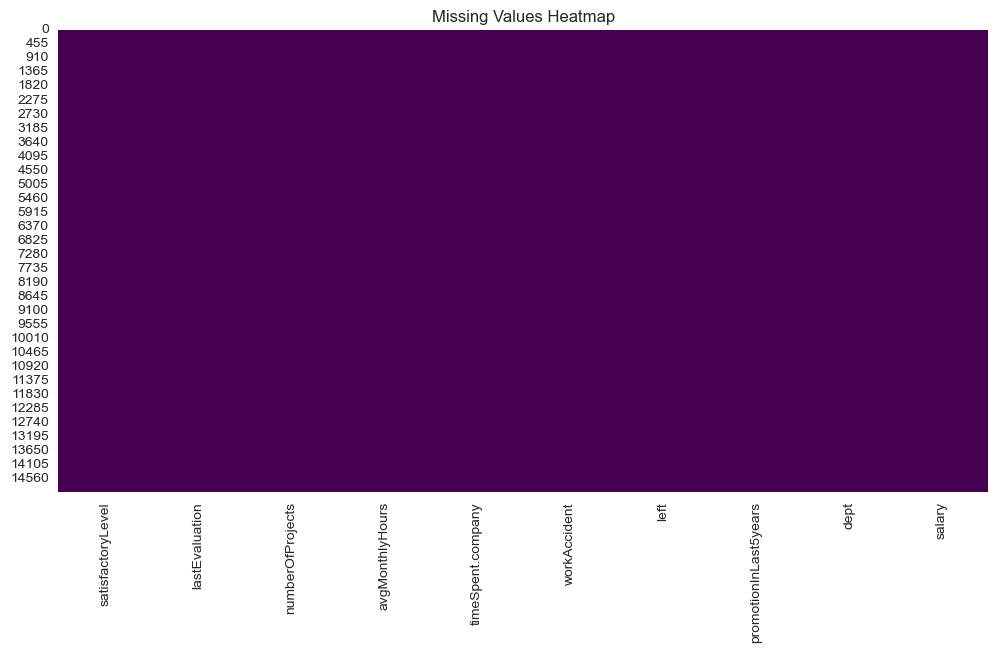

In [10]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [11]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 3008


In [12]:
df.drop_duplicates(inplace=True)

print("Shape After Removing Duplicates")
print(df.shape)

Shape After Removing Duplicates
(11991, 10)


In [13]:
df.nunique()

satisfactoryLevel         92
lastEvaluation            65
numberOfProjects           6
avgMonthlyHours          215
timeSpent.company          8
workAccident               2
left                       2
promotionInLast5years      2
dept                      10
salary                     3
dtype: int64

In [14]:
df.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low


In [ ]:
# Initial Observations

At this stage:

- Dataset successfully loaded
- Checked dimensions
- Checked data types
- Removed duplicate records
- Checked missing values
- Understood available features

The dataset is now ready for Exploratory Data Analysis.

In [15]:
df.rename(columns={'timeSpent.company':'time_spent_company'}, inplace=True)

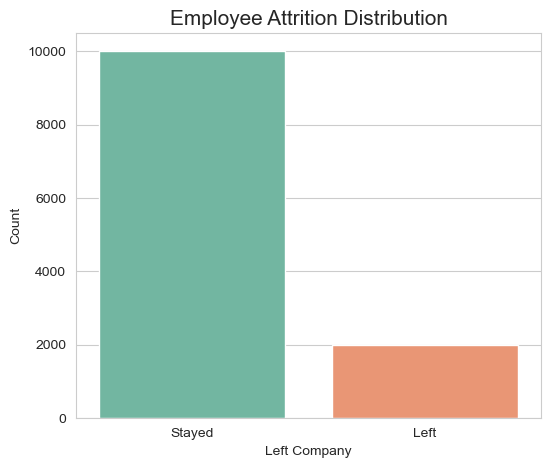

In [16]:
plt.figure(figsize=(6,5))
sns.countplot(x='left', data=df, palette='Set2')

plt.title("Employee Attrition Distribution", fontsize=15)
plt.xlabel("Left Company")
plt.ylabel("Count")

plt.xticks([0,1],["Stayed","Left"])

plt.show()

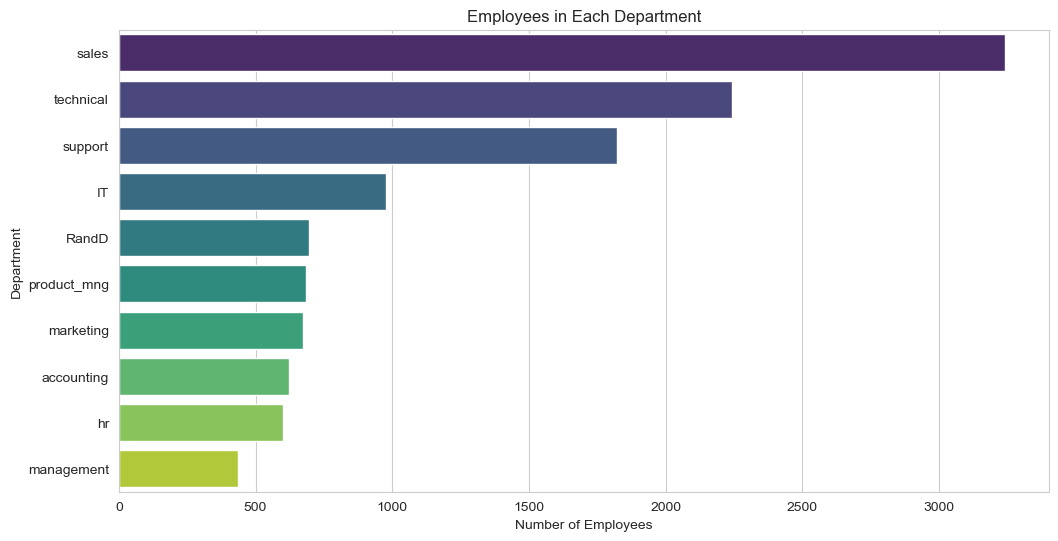

In [17]:
plt.figure(figsize=(12,6))

sns.countplot(y='dept',
              data=df,
              order=df['dept'].value_counts().index,
              palette='viridis')

plt.title("Employees in Each Department")
plt.xlabel("Number of Employees")
plt.ylabel("Department")

plt.show()

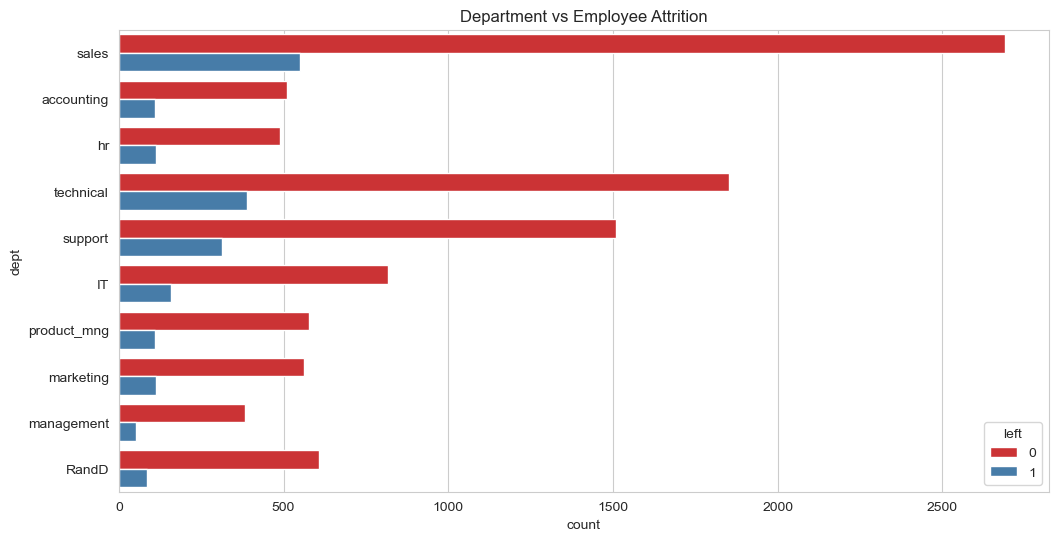

In [18]:
plt.figure(figsize=(12,6))

sns.countplot(y='dept',
              hue='left',
              data=df,
              palette='Set1')

plt.title("Department vs Employee Attrition")

plt.show()

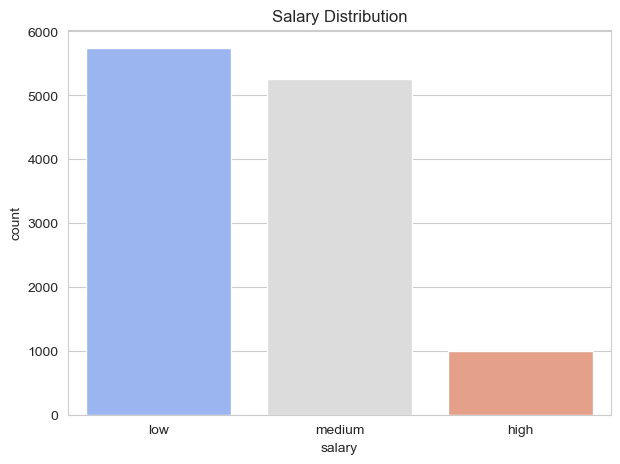

In [19]:
plt.figure(figsize=(7,5))

sns.countplot(x='salary',
              data=df,
              order=['low','medium','high'],
              palette='coolwarm')

plt.title("Salary Distribution")

plt.show()

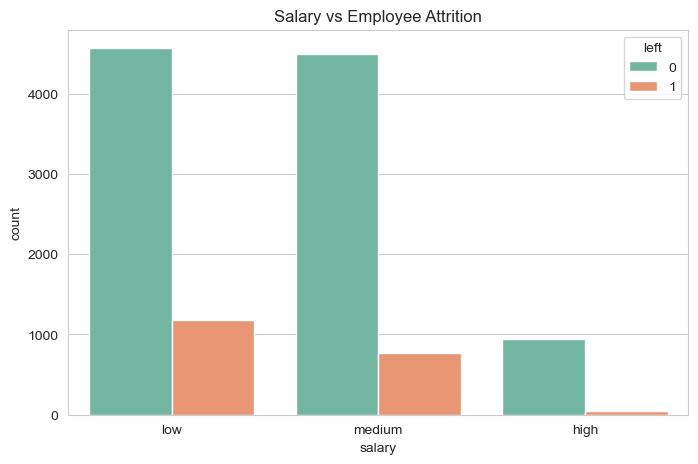

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(x='salary',
              hue='left',
              data=df,
              order=['low','medium','high'],
              palette='Set2')

plt.title("Salary vs Employee Attrition")

plt.show()

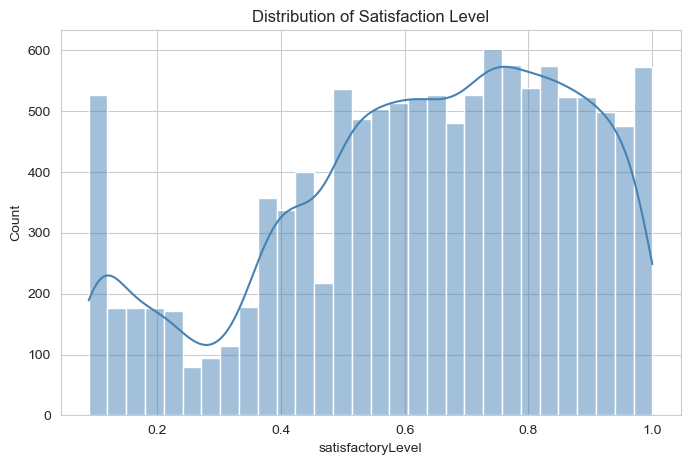

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df['satisfactoryLevel'],
             bins=30,
             kde=True,
             color='steelblue')

plt.title("Distribution of Satisfaction Level")

plt.show()

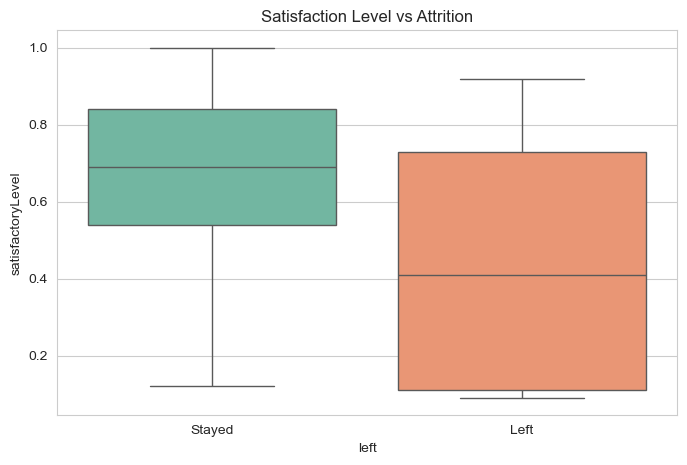

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(x='left',
            y='satisfactoryLevel',
            data=df,
            palette='Set2')

plt.xticks([0,1],["Stayed","Left"])

plt.title("Satisfaction Level vs Attrition")

plt.show()

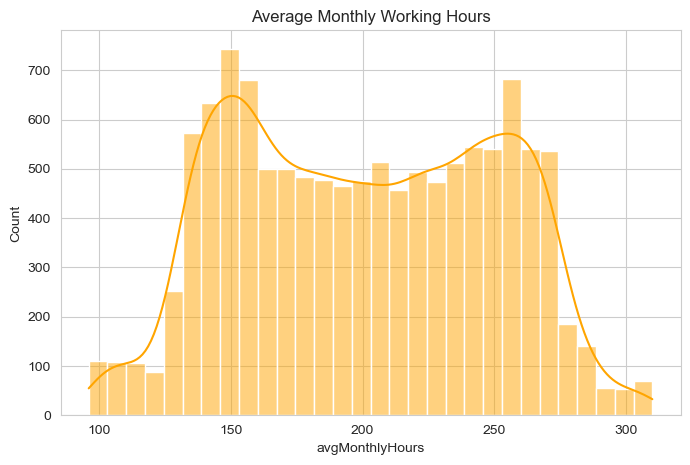

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df['avgMonthlyHours'],
             bins=30,
             kde=True,
             color='orange')

plt.title("Average Monthly Working Hours")

plt.show()

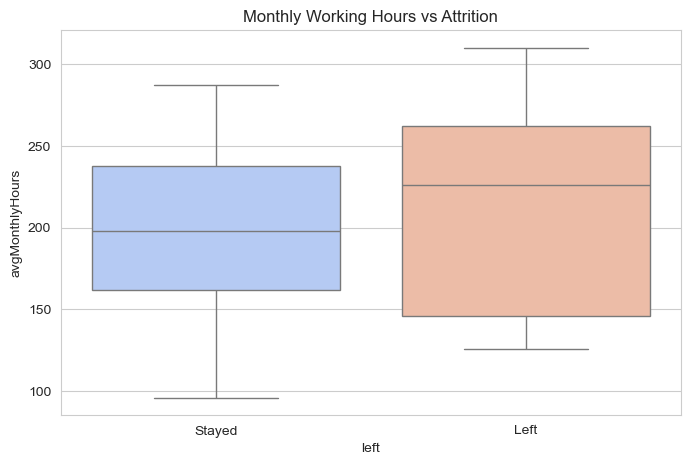

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(x='left',
            y='avgMonthlyHours',
            data=df,
            palette='coolwarm')

plt.xticks([0,1],["Stayed","Left"])

plt.title("Monthly Working Hours vs Attrition")

plt.show()

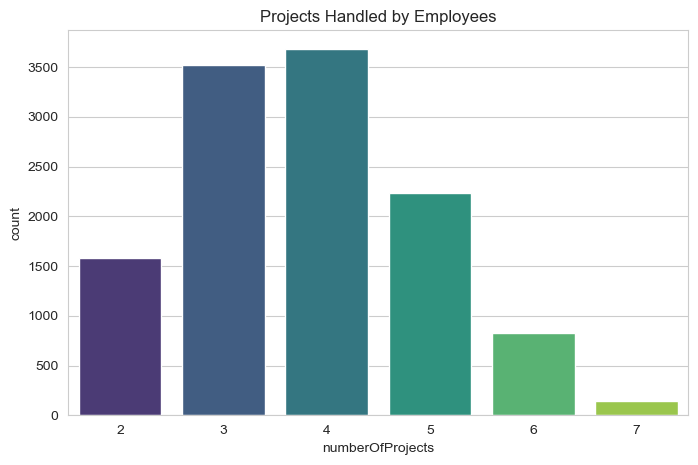

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(x='numberOfProjects',
              data=df,
              palette='viridis')

plt.title("Projects Handled by Employees")

plt.show()

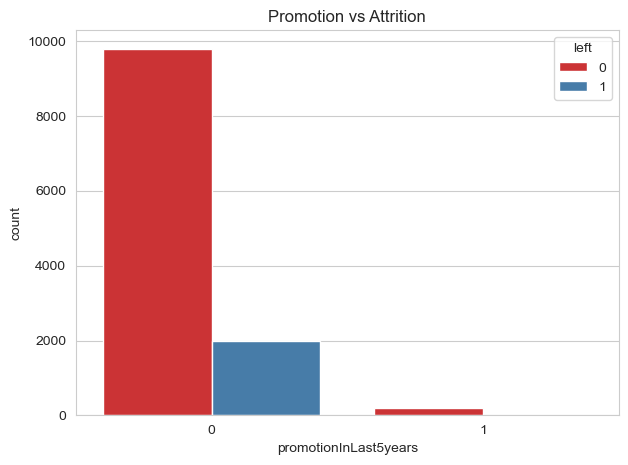

In [26]:
plt.figure(figsize=(7,5))

sns.countplot(x='promotionInLast5years',
              hue='left',
              data=df,
              palette='Set1')

plt.title("Promotion vs Attrition")

plt.show()

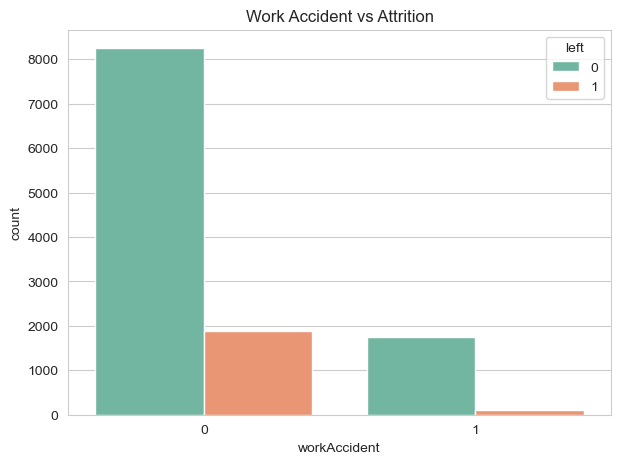

In [27]:
plt.figure(figsize=(7,5))

sns.countplot(x='workAccident',
              hue='left',
              data=df,
              palette='Set2')

plt.title("Work Accident vs Attrition")

plt.show()

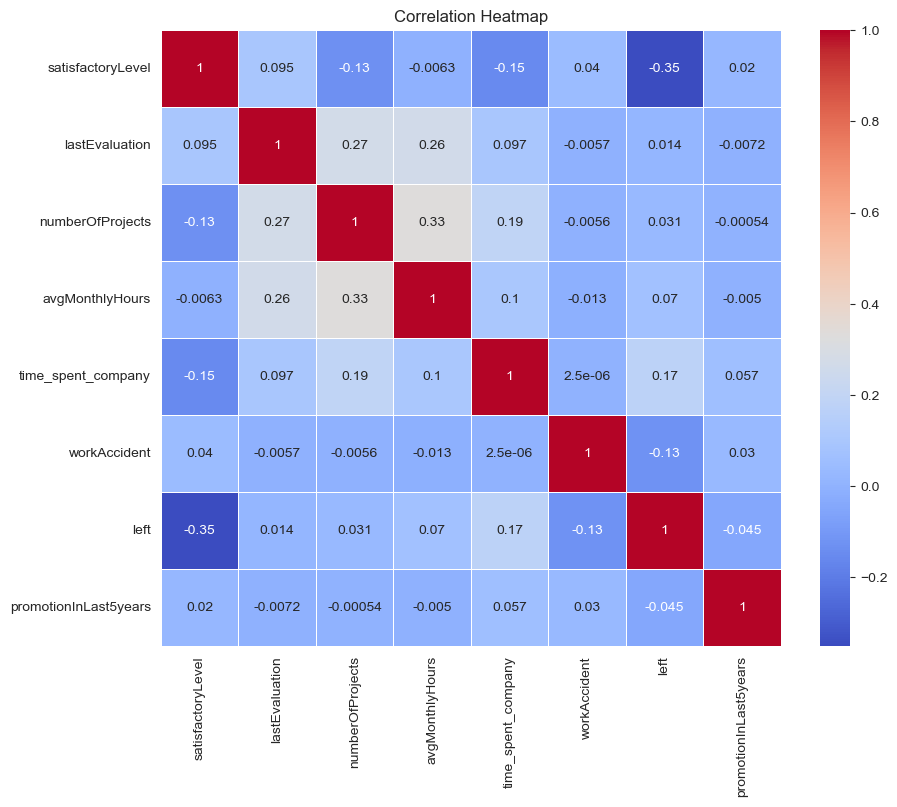

In [28]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
## Key Insights from EDA

- The dataset contains no missing values.
- Employees with lower satisfaction levels are more likely to leave.
- Low-salary employees exhibit higher attrition.
- Departments show varying attrition rates.
- Employees working extremely high monthly hours are more likely to leave.
- Promotion appears to reduce employee attrition.
- Correlation analysis highlights relationships among numerical variables that can assist model building.

In [ ]:
# Data Preprocessing

Before training machine learning models, categorical variables are converted into numerical form, features are scaled, and the dataset is split into training and testing sets.

In [29]:
df.rename(columns={'timeSpent.company':'time_spent_company'}, inplace=True)

df.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,time_spent_company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low


In [30]:
salary_mapping = {
    'low':0,
    'medium':1,
    'high':2
}

df['salary'] = df['salary'].map(salary_mapping)

In [31]:
df = pd.get_dummies(df,
                    columns=['dept'],
                    drop_first=True)

df.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,time_spent_company,workAccident,left,promotionInLast5years,salary,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,True,False,False
3,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,True,False,False
4,0.41,0.50,2,153,3,0,1,0,0,False,False,False,False,False,False,True,False,False


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 14998
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfactoryLevel      11991 non-null  float64
 1   lastEvaluation         11991 non-null  float64
 2   numberOfProjects       11991 non-null  int64  
 3   avgMonthlyHours        11991 non-null  int64  
 4   time_spent_company     11991 non-null  int64  
 5   workAccident           11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotionInLast5years  11991 non-null  int64  
 8   salary                 11991 non-null  int64  
 9   dept_RandD             11991 non-null  bool   
 10  dept_accounting        11991 non-null  bool   
 11  dept_hr                11991 non-null  bool   
 12  dept_management        11991 non-null  bool   
 13  dept_marketing         11991 non-null  bool   
 14  dept_product_mng       11991 non-null  bool   
 15  dept_sa

In [33]:
X = df.drop('left', axis=1)

y = df['left']

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (9592, 17)
Testing Samples : (2399, 17)


In [36]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [37]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [38]:
y_pred_log = log_model.predict(X_test)

In [39]:
log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy : {:.2f}%".format(log_accuracy*100))

Logistic Regression Accuracy : 82.95%


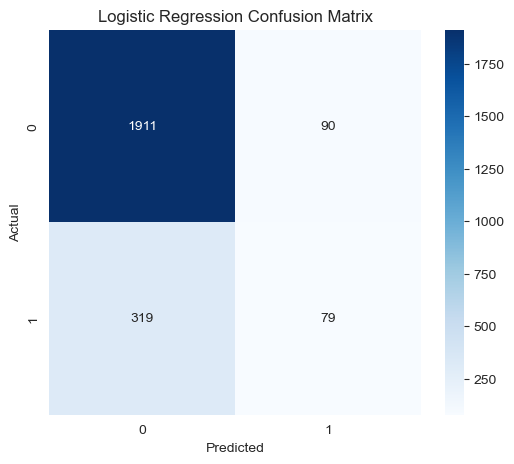

In [40]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [41]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.86      0.96      0.90      2001
           1       0.47      0.20      0.28       398

    accuracy                           0.83      2399
   macro avg       0.66      0.58      0.59      2399
weighted avg       0.79      0.83      0.80      2399



In [ ]:
## Logistic Regression Observation

The Logistic Regression model provides a baseline performance for employee attrition prediction. The confusion matrix and classification report help evaluate precision, recall, and F1-score.

In [ ]:
# Decision Tree Classifier

Decision Trees split the dataset into decision nodes based on feature importance, making them useful for capturing non-linear relationships in employee attrition data.

In [42]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [43]:
y_pred_dt = dt_model.predict(X_test)

In [44]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy : {:.2f}%".format(dt_accuracy*100))

Decision Tree Accuracy : 98.00%


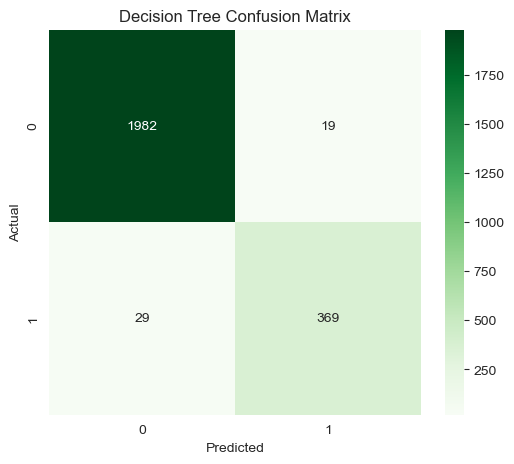

In [45]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

In [46]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2001
           1       0.95      0.93      0.94       398

    accuracy                           0.98      2399
   macro avg       0.97      0.96      0.96      2399
weighted avg       0.98      0.98      0.98      2399



In [ ]:
# Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [49]:
y_pred_rf = rf_model.predict(X_test)

In [50]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy : {:.2f}%".format(rf_accuracy*100))

Random Forest Accuracy : 98.46%


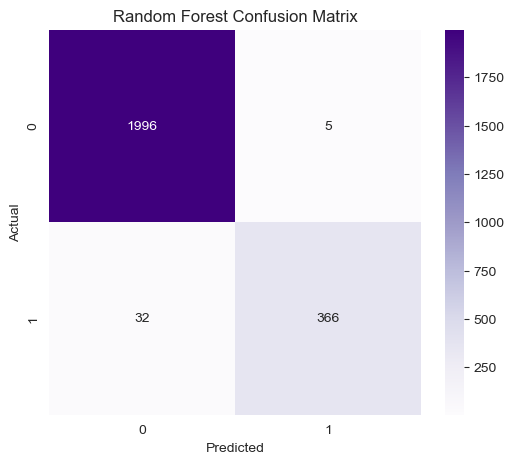

In [51]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Purples')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [52]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2001
           1       0.99      0.92      0.95       398

    accuracy                           0.98      2399
   macro avg       0.99      0.96      0.97      2399
weighted avg       0.98      0.98      0.98      2399



In [53]:
from sklearn.metrics import roc_curve, auc

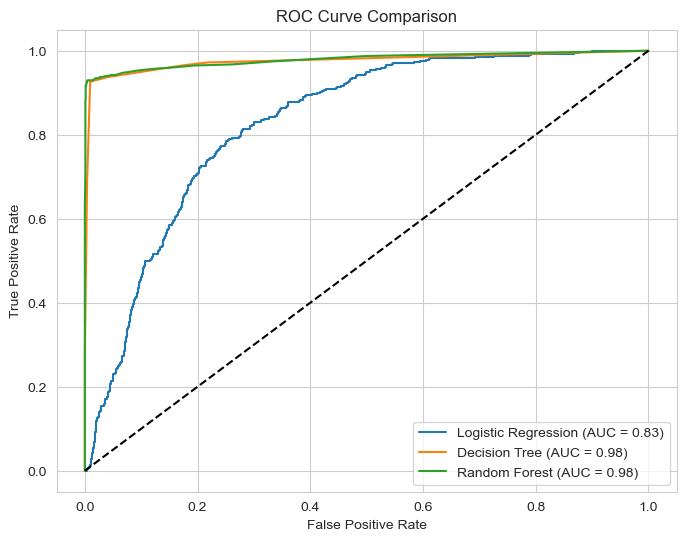

In [54]:
models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

plt.figure(figsize=(8,6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.plot(fpr,
             tpr,
             label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [55]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
0,satisfactoryLevel,0.327027
2,numberOfProjects,0.175720
4,time_spent_company,0.168038
3,avgMonthlyHours,0.160453
1,lastEvaluation,0.132713
7,salary,0.010051
5,workAccident,0.006513
14,dept_sales,0.003327
16,dept_technical,0.003146
15,dept_support,0.002765


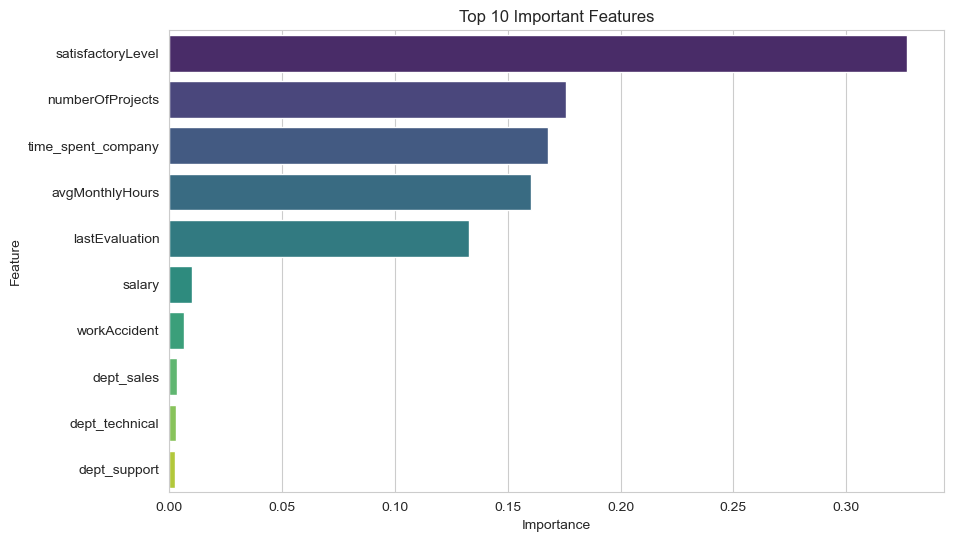

In [56]:
plt.figure(figsize=(10,6))

sns.barplot(data=importance.head(10),
            x="Importance",
            y="Feature",
            palette="viridis")

plt.title("Top 10 Important Features")

plt.show()

In [57]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        log_accuracy,
        dt_accuracy,
        rf_accuracy
    ]

})

results["Accuracy"] = results["Accuracy"]*100

results

,Model,Accuracy
0,Logistic Regression,82.951230
1,Decision Tree,97.999166
2,Random Forest,98.457691


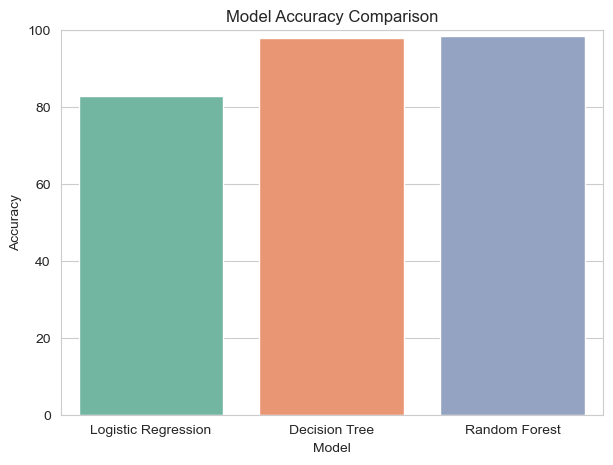

In [58]:
plt.figure(figsize=(7,5))

sns.barplot(data=results,
            x="Model",
            y="Accuracy",
            palette="Set2")

plt.ylim(0,100)

plt.title("Model Accuracy Comparison")

plt.show()

In [59]:
best = results.sort_values(
    by="Accuracy",
    ascending=False
)

best

,Model,Accuracy
2,Random Forest,98.457691
1,Decision Tree,97.999166
0,Logistic Regression,82.951230


In [ ]:
# Conclusion

This project analyzed employee attrition using HR analytics data and developed machine learning models to predict employee turnover.

### Summary

- Performed comprehensive data cleaning and preprocessing.
- Conducted Exploratory Data Analysis (EDA) to identify trends affecting employee attrition.
- Encoded categorical variables and standardized numerical features.
- Built three classification models:
  - Logistic Regression
  - Decision Tree
  - Random Forest
- Compared model performance using accuracy, confusion matrices, classification reports, and ROC curves.
- Identified the best-performing model based on predictive accuracy.

### Business Insights

- Employees with low satisfaction levels are more likely to leave.
- Employees receiving low salaries exhibit higher attrition.
- Promotions appear to reduce employee turnover.
- Departments show different attrition patterns.
- Working excessive monthly hours may contribute to employee attrition.

The resulting model can help organizations identify employees at higher risk of leaving and support data-driven retention strategies.

In [60]:
import joblib

joblib.dump(rf_model, "employee_attrition_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
